In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score, roc_curve)
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("/content/train.csv")

print("Original data:")
print(df.head())
print("\nShape:", df.shape)

Original data:
   patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0           1   74   Other         130/72          240  31.5      Yes   
1           2   46  Female         120/92          292  36.3       No   
2           3   89   Other         135/78          153  30.3       No   
3           4   84  Female         123/80          153  31.5       No   
4           5   32   Other         135/84          205  18.4       No   

  hypertension  medication_count  length_of_stay discharge_destination  \
0           No                 5               1      Nursing_Facility   
1           No                 4               3      Nursing_Facility   
2          Yes                 1               1                  Home   
3          Yes                 3              10                  Home   
4          Yes                 6               4      Nursing_Facility   

  readmitted_30_days  
0                Yes  
1                 No  
2                 No  
3        

In [3]:
df[["systolic_bp", "diastolic_bp"]] = df["blood_pressure"].str.split(
    "/", expand=True
).astype(float)

In [4]:
df.drop(["patient_id", "blood_pressure"], axis=1, inplace=True)

In [5]:
df["diabetes"] = df["diabetes"].map({
    "Yes": 1,
    "No": 0
})

df["hypertension"] = df["hypertension"].map({
    "Yes": 1,
    "No": 0
})

df["readmitted_30_days"] = df["readmitted_30_days"].map({
    "Yes": 1,
    "No": 0
})

In [6]:
df = pd.get_dummies(
    df,
    columns=["gender", "discharge_destination"],
    drop_first=True
)
df = df.dropna()

In [7]:
print("\nData after preprocessing:")
print(df.head())

print("\nShape after removing NaN:", df.shape)


Data after preprocessing:
   age  cholesterol   bmi  diabetes  hypertension  medication_count  \
0   74          240  31.5         1             0                 5   
1   46          292  36.3         0             0                 4   
2   89          153  30.3         0             1                 1   
3   84          153  31.5         0             1                 3   
4   32          205  18.4         0             1                 6   

   length_of_stay  readmitted_30_days  systolic_bp  diastolic_bp  gender_Male  \
0               1                   1        130.0          72.0        False   
1               3                   0        120.0          92.0        False   
2               1                   0        135.0          78.0        False   
3              10                   0        123.0          80.0        False   
4               4                   0        135.0          84.0        False   

   gender_Other  discharge_destination_Nursing_Facility  \


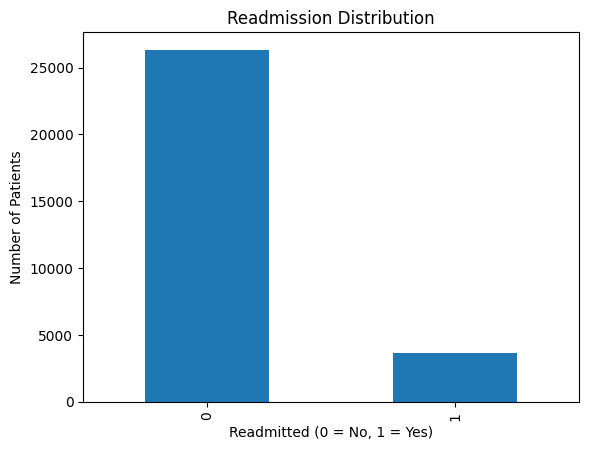

In [8]:
df["readmitted_30_days"].value_counts().plot(kind="bar")
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.title("Readmission Distribution")
plt.show()

In [9]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (24000, 13)
Testing data: (6000, 13)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression(
    penalty="l2",
    max_iter=1000,
    class_weight="balanced"
)

In [13]:
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [14]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

In [15]:
auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC:", auc)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


ROC-AUC: 0.5633619525683018

Accuracy: 0.6698333333333333

Confusion Matrix:
[[3723 1542]
 [ 439  296]]


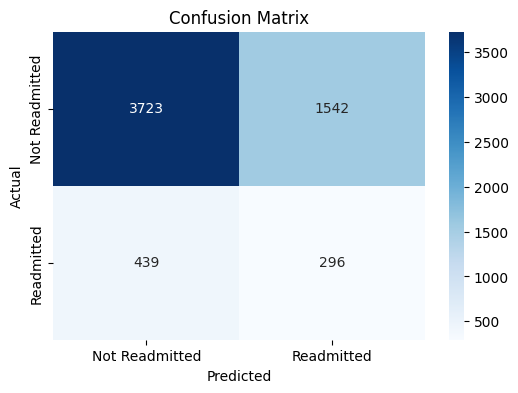

In [16]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

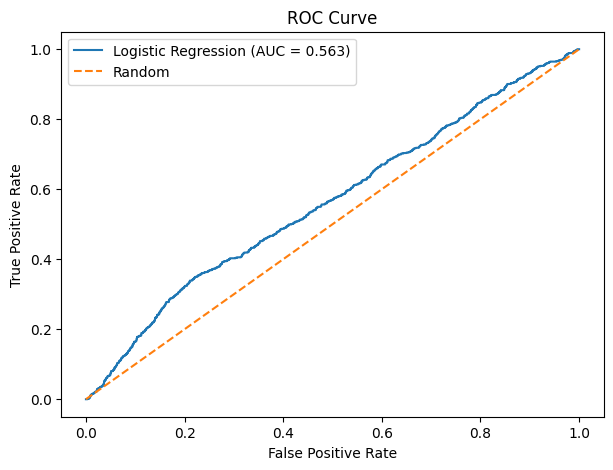

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
TN, FP, FN, TP = cm.ravel()

print("\nFalse Negatives:", FN)
print("False Positives:", FP)


False Negatives: 439
False Positives: 1542


In [19]:
print("\nFirst 10 predicted readmission probabilities:")
print(y_prob[:10])


First 10 predicted readmission probabilities:
[0.46948681 0.57412532 0.44021458 0.5724725  0.49336951 0.56709066
 0.4434475  0.58838145 0.38085975 0.45794022]


In [20]:
print('''False Negatives vs False Positives

A false negative is a patient the model says won't come back, but who does get readmitted. That patient goes home without extra follow-up and can come back in worse condition, and the hospital also gets penalised for the readmission. So this is the costly mistake.

A false positive is a patient flagged as high risk who would have been fine. It only costs an extra follow-up call or check-up, which is much cheaper than a missed patient.

Readmitted patients are a small part of the data, so I used class_weight="balanced". Without it the model predicts "No" for almost everyone, gets good accuracy and misses the readmissions. With it we get more false positives but fewer false negatives, which is better in a hospital. This is why accuracy alone is not a good measure here and ROC-AUC is used.''')

False Negatives vs False Positives

A false negative is a patient the model says won't come back, but who does get readmitted. That patient goes home without extra follow-up and can come back in worse condition, and the hospital also gets penalised for the readmission. So this is the costly mistake.

A false positive is a patient flagged as high risk who would have been fine. It only costs an extra follow-up call or check-up, which is much cheaper than a missed patient.

Readmitted patients are a small part of the data, so I used class_weight="balanced". Without it the model predicts "No" for almost everyone, gets good accuracy and misses the readmissions. With it we get more false positives but fewer false negatives, which is better in a hospital. This is why accuracy alone is not a good measure here and ROC-AUC is used.
